# PyPAS Transport Solver — Analytical Benchmark

Two independent benchmarks validate `profile_solver` against exact closed-form results.

**Benchmark 1 — Surface annihilation fraction (2D parameter scan)**
For a semi-infinite homogeneous medium the exact surface fraction is the
integral transform $f = \int I(z)\,e^{-z/L}\,dz\,/\,(1 + L_a/L)$.
A 2D color map over $(L,\,L_a)$ space reveals where the FD solver agrees and
where accuracy degrades (mesh resolution or sample-thickness limits).

**Benchmark 2 — Full annihilation profile (constant source, electric field)**
For a constant source $I_0$ and constant coefficients $(D,\,v=\mu E,\,\lambda)$
the transport equation has the exact solution
$$c(z) = \tilde{A}\,e^{\kappa_1(z-L)} + B\,e^{\kappa_2 z} + \frac{I_0}{\lambda}$$
where $\kappa_{1,2} = v/(2D)\pm\sqrt{(v/2D)^2+1/L_+^2}$ and the constants
$\tilde{A}, B$ are determined analytically from the two radiative BCs.
The stable substitution $\tilde{A}=Ae^{\kappa_1 L}$ avoids the $e^{\kappa_1 L}\sim 10^{43}$
factor that makes the naive BC matrix singular in double precision.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import xarray as xr
from pyPAS.transport import (
    makhov_material_parameters, makhov_profile,
    multilayer_implantation_profile, profile_solver,
)
from pyPAS.model import Material, Layer, Sample
from pyPAS.analysis import compute_annihilation_fractions

## 1. 2D color map: surface fraction relative error vs (L, Lₐ)

For each $(L,\,L_a)$ pair in a 30×30 log-spaced grid from 1 to 10 000 nm the FD solver
is run and its surface fraction compared to the analytical integral transform.

Accuracy degrades at two limits visible in the plot:
- **Small L** (approaching $\Delta z = 0.1$ nm): the diffusion profile is under-resolved.
- **Large L** (approaching sample length 10 000 nm): the semi-infinite approximation fails.

*Settings: Cu 10 keV Makhov profile, 100 000 mesh cells, sample length 10 000 nm.*

In [2]:
D             = 1.0
mesh_size_1   = 100_000
sample_len_1  = 10_000.0   # nm  →  Δz = 0.1 nm
beam_energy   = 10.0       # keV

Cu_params = makhov_material_parameters().iloc[9].copy()
Cu_params['density'] = 8.96

depth = np.linspace(0, sample_len_1, 20_000)
prof_1kev = multilayer_implantation_profile(
    beam_energy, depth, [sample_len_1],
    [Cu_params], [Cu_params['density']], makhov_profile)
x_p, y_p = prof_1kev.coords['x'].values, prof_1kev.values

N_pts   = 30
L_grid  = np.logspace(0, 4, N_pts)
La_grid = np.logspace(0, 4, N_pts)
print(f'Grid: {N_pts}x{N_pts} = {N_pts**2} points  |  dz = {sample_len_1/mesh_size_1:.2f} nm')

Grid: 30x30 = 900 points  |  dz = 0.10 nm


In [3]:
# ── 2D scan — typically takes 1–2 minutes ────────────────────────────────────
error_map = np.full((N_pts, N_pts), np.nan)
for i, La in enumerate(La_grid):
    for j, L in enumerate(L_grid):
        lam   = D / L**2
        layer = Layer(width=sample_len_1,
                      material=Material(diffusion=D, mobility=0,
                                         bulk_annihilation_rate=lam))
        sample = Sample(layers=[layer], absorption_length=La)
        ann   = profile_solver(prof_1kev, sample, mesh_size=mesh_size_1)
        f_num = float(compute_annihilation_fractions(ann, sample).sel(layer=-1))
        f_ref = float(np.trapezoid(y_p * np.exp(-x_p/L), x_p)) / (1 + La/L)
        if f_ref > 0:
            error_map[i, j] = 100 * abs(f_num - f_ref) / f_ref
# ─────────────────────────────────────────────────────────────────────────────
print(f'Max error: {np.nanmax(error_map):.3f}%   Median: {np.nanmedian(error_map):.4f}%')

Max error: 22.958%   Median: 0.0157%


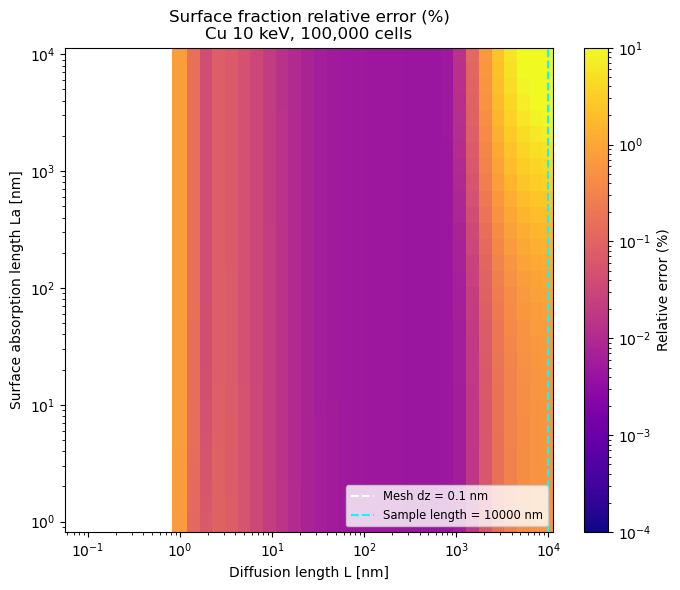

In [4]:
L_mesh, La_mesh = np.meshgrid(L_grid, La_grid)
fig, ax = plt.subplots(figsize=(7, 6))
pcm = ax.pcolormesh(L_mesh, La_mesh, error_map,
                    norm=mcolors.LogNorm(vmin=1e-4, vmax=10.0),
                    cmap='plasma', shading='auto')
fig.colorbar(pcm, ax=ax, label='Relative error (%)')
ax.axvline(sample_len_1/mesh_size_1, color='white', ls='--', lw=1.5,
           label=f'Mesh dz = {sample_len_1/mesh_size_1:.1f} nm')
ax.axvline(sample_len_1, color='cyan', ls='--', lw=1.5,
           label=f'Sample length = {sample_len_1:.0f} nm')
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('Diffusion length L [nm]')
ax.set_ylabel('Surface absorption length La [nm]')
ax.set_title(f'Surface fraction relative error (%)\n'
             f'Cu {beam_energy:.0f} keV, {mesh_size_1:,} cells')
ax.legend(fontsize='small', loc='lower right')
plt.tight_layout(); plt.show()

## 2. Full profile benchmark: constant source with electric field

Parameters: $D=1$ nm²/ps, $\mu=1$ nm²/(ps·V), $E=1$ V/nm, $L_a=1$ nm,
$L_+=100$ nm, sample length $= L_+ = 100$ nm, 100 000 mesh cells.

With $\Delta z = 100/100\,000 = 0.001$ nm the expected FD truncation error is:
$$\left(\frac{\Delta z}{L_+}\right)^2 = \left(\frac{0.001}{100}\right)^2 = 10^{-10}$$

The source is a **uniform (constant) distribution** $I_0 = 1$, for which the exact
solution is known in closed form. The two panels show the excellent agreement
between the FD solver and the analytical solution, and the point-wise relative
difference which reaches down toward $10^{-10}$.

In [5]:
# Parameters — all natural constants set to 1
D_2        = 1.0        # nm²/ps
mobility_2 = 1.0        # nm²/(ps·V)
E_2        = 1.0        # V/nm
v_2        = mobility_2 * E_2  # nm/ps
L_a_2      = 1.0        # nm
L_diff_2   = 100.0      # nm  (positron diffusion length)
lam_2      = D_2 / L_diff_2**2
I0_2       = 1.0        # constant source amplitude
L_2        = 100.0      # nm  sample length  (= L_diff_2)
mesh_2     = 100_000

# Characteristic exponents of the homogeneous equation
kappa_1 = v_2/(2*D_2) + np.sqrt((v_2/(2*D_2))**2 + 1/L_diff_2**2)
kappa_2 = v_2/(2*D_2) - np.sqrt((v_2/(2*D_2))**2 + 1/L_diff_2**2)

# Stable BC system:  unknowns are A_tilde = A*exp(kappa_1*L) and B
# c(z) = A_tilde*exp(kappa_1*(z-L)) + B*exp(kappa_2*z) + I0/lam
bc_mat = np.array([
    [np.exp(-kappa_1*L_2)*(kappa_1 - 1/L_a_2),  kappa_2 - 1/L_a_2],
    [kappa_1 + 1/L_diff_2,  np.exp(kappa_2*L_2)*(kappa_2 + 1/L_diff_2)]
])
rhs_bc  = np.array([(I0_2/lam_2)/L_a_2, -(I0_2/lam_2)/L_diff_2])
A_tilde, B_coef = np.linalg.solve(bc_mat, rhs_bc)

def c_analytical(z):
    return A_tilde*np.exp(kappa_1*(z-L_2)) + B_coef*np.exp(kappa_2*z) + I0_2/lam_2

print(f'kappa_1 = {kappa_1:.6f} nm^-1   kappa_2 = {kappa_2:.8f} nm^-1')
print(f'A_tilde = {A_tilde:.4f}   B = {B_coef:.4f}')
print(f'c(0)  = {c_analytical(0):.6f}  (≈ I0/v = {I0_2/v_2:.1f})')
print(f'c(L)  = {c_analytical(L_2):.4f}')
print(f'Expected FD error ~ (dz/L+)^2 = {(L_2/mesh_2/L_diff_2)**2:.1e}')

kappa_1 = 1.000100 nm^-1   kappa_2 = -0.00009999 nm^-1
A_tilde = -1.9747   B = -9999.0002
c(0)  = 0.999800  (≈ I0/v = 1.0)
c(L)  = 98.5069
Expected FD error ~ (dz/L+)^2 = 1.0e-10


In [6]:
layer_2 = Layer(width=L_2,
                material=Material(diffusion=D_2, mobility=mobility_2,
                                   bulk_annihilation_rate=lam_2))
sample_2 = Sample(layers=[layer_2], absorption_length=L_a_2)

mpts_2  = np.linspace(0, L_2, mesh_2)
src_2   = xr.DataArray(I0_2 * np.ones(mesh_2), coords={'x': mpts_2})
ef_2    = xr.DataArray(np.full(mesh_2, E_2),   coords={'x': mpts_2})

c_fd_2  = profile_solver(src_2, sample_2, electric_field=ef_2, mesh_size=mesh_2)
z_2     = c_fd_2.coords['x'].values
c_ref_2 = c_analytical(z_2)
rel_2   = np.abs(c_fd_2.values - c_ref_2) / np.abs(c_ref_2)
mask_2  = c_ref_2 > 0.01 * c_ref_2.max()

print(f'c(0) numerical  = {c_fd_2.values[0]:.6f}')
print(f'c(0) analytical = {c_analytical(0):.6f}')
print(f'Max relative error: {rel_2[mask_2].max():.2e}')
print(f'Min relative error: {rel_2[mask_2].min():.2e}')

c(0) numerical  = 0.999800
c(0) analytical = 0.999800
Max relative error: 1.11e-08
Min relative error: 9.78e-15


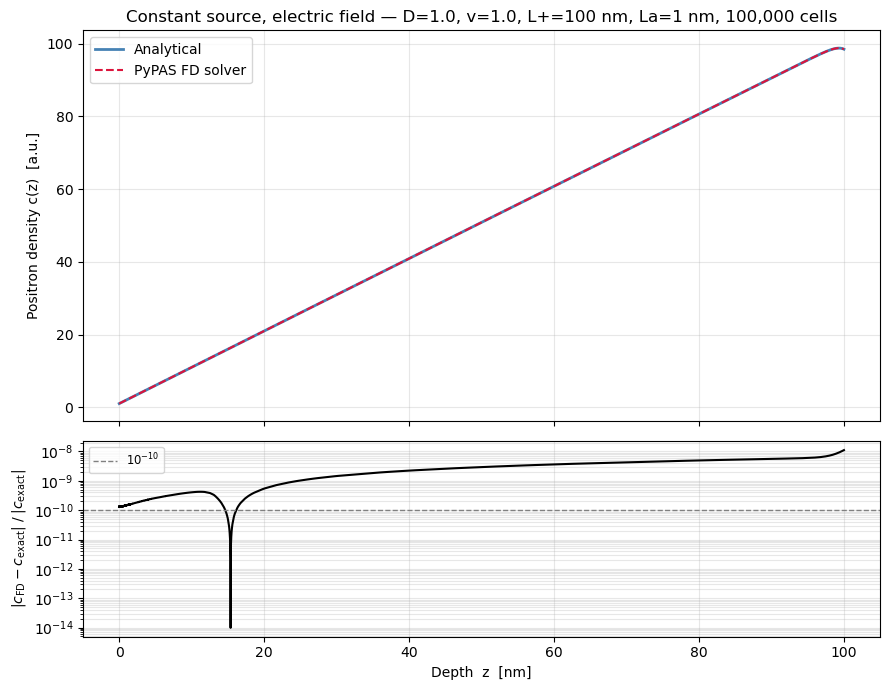

In [7]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 7), sharex=True,
                                gridspec_kw={'height_ratios': [2, 1]})

ax1.plot(z_2, c_ref_2,         '-',  color='steelblue', lw=2,   label='Analytical')
ax1.plot(z_2, c_fd_2.values, '--', color='crimson',   lw=1.5, label='PyPAS FD solver')
ax1.set_ylabel('Positron density c(z)  [a.u.]')
ax1.set_title(f'Constant source, electric field — D={D_2}, v={v_2}, '
              f'L+={L_diff_2:.0f} nm, La={L_a_2:.0f} nm, {mesh_2:,} cells')
ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.semilogy(z_2[mask_2], rel_2[mask_2], color='black', lw=1.5)
ax2.axhline(1e-10, color='gray', ls='--', lw=1, label=r'$10^{-10}$')
ax2.set_ylabel(r'$|c_\mathrm{FD} - c_\mathrm{exact}| \;/\; |c_\mathrm{exact}|$')
ax2.set_xlabel('Depth  z  [nm]')
ax2.legend(fontsize='small'); ax2.grid(True, alpha=0.3, which='both')

plt.tight_layout(); plt.show()

## 3. Convergence with mesh size

The FD scheme is second-order accurate: the error scales as $O(\Delta z^2) = O(N^{-2})$.

N =   1,000  dz = 0.10000 nm  max rel error = 4.97e-05
N =   3,000  dz = 0.03333 nm  max rel error = 5.52e-06
N =  10,000  dz = 0.01000 nm  max rel error = 4.96e-07
N =  30,000  dz = 0.00333 nm  max rel error = 5.57e-08
N = 100,000  dz = 0.00100 nm  max rel error = 1.11e-08


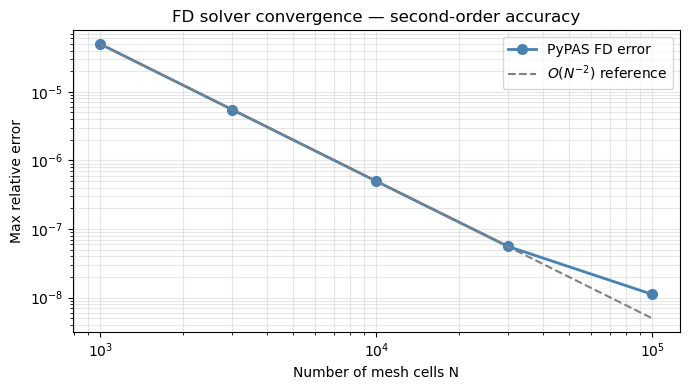

In [8]:
mesh_sizes = [1_000, 3_000, 10_000, 30_000, 100_000]
max_errors = []

for N in mesh_sizes:
    mpts = np.linspace(0, L_2, N)
    src_ = xr.DataArray(I0_2*np.ones(N), coords={'x': mpts})
    ef_  = xr.DataArray(np.full(N, E_2), coords={'x': mpts})
    c_   = profile_solver(src_, sample_2, electric_field=ef_, mesh_size=N)
    z_   = c_.coords['x'].values
    ref_ = c_analytical(z_)
    rel_ = np.abs(c_.values - ref_) / np.abs(ref_)
    err  = rel_[ref_ > 0.01*ref_.max()].max()
    max_errors.append(err)
    print(f'N = {N:>7,}  dz = {L_2/N:.5f} nm  max rel error = {err:.2e}')

fig, ax = plt.subplots(figsize=(7, 4))
ax.loglog(mesh_sizes, max_errors, 'o-', color='steelblue', lw=2, markersize=7,
          label='PyPAS FD error')
N_r = np.array([mesh_sizes[0], mesh_sizes[-1]], dtype=float)
ax.loglog(N_r, max_errors[0]*(N_r[0]/N_r)**2, '--', color='gray',
          label=r'$O(N^{-2})$ reference')
ax.set_xlabel('Number of mesh cells N')
ax.set_ylabel('Max relative error')
ax.set_title('FD solver convergence — second-order accuracy')
ax.legend(); ax.grid(True, which='both', alpha=0.3)
plt.tight_layout(); plt.show()